In [1]:
"""
Clasificador de Cristales PET — Bien / Mal / Poca Densidad
===========================================================
EfficientNet-B0 con fine-tuning y corrección de desbalance de clases.
Resize a 600 el lado corto.

Estructura de carpetas:
    data/
    └── raw/
        ├── bien/          (567 imágenes)
        ├── mal/           (2063 imágenes)
        └── poca_densidad/ (314 imágenes)

Requisitos:
    pip install torch torchvision matplotlib tqdm pillow
"""

'\nClasificador de Cristales PET — Bien / Mal / Poca Densidad\n===========================================================\nEfficientNet-B0 con fine-tuning y corrección de desbalance de clases.\nResize a 600 el lado corto.\n\nEstructura de carpetas:\n    data/\n    └── raw/\n        ├── bien/          (567 imágenes)\n        ├── mal/           (2063 imágenes)\n        └── poca_densidad/ (314 imágenes)\n\nRequisitos:\n    pip install torch torchvision matplotlib tqdm pillow\n'

In [2]:
import os
import random
import shutil
import numpy as np
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
from tqdm import tqdm

from google.colab import drive
drive.mount('/content/drive')

import shutil
shutil.copytree(
    "/content/drive/MyDrive/00_MASTER/TFM/data",  # ruta a la carpeta en Drive
    "/content/data"                  # donde la quiere el código
)

Mounted at /content/drive


'/content/data'

In [15]:
# ─────────────────────────────────────────────
# 0. CONFIGURACIÓN
# ─────────────────────────────────────────────

CONFIG = {
    # Rutas
    "raw_dir":    "/content/data/raw",
    "train_dir":  "/content/data/train",
    "val_dir":    "/content/data/val",

    # Modelo
    "img_size":      224, #modificar en imágenes de 300x300
    "num_classes":   3,
    "model_name":    "efficientnet_b0",

    # Entrenamiento
    "epochs":          35,
    "batch_size":      32, #en imágenes 300x300, dar valor de 16
    "lr":              1e-4,
    "val_split":       0.2,
    "freeze_backbone": True,
    "unfreeze_epoch":  12,

    # Checkpoints
    "checkpoint_dir": "/content/checkpoints_cristales",
    "best_model":     "/content/checkpoints_cristales/mejor_modelo.pth",

    "seed": 42,
}

# Orden alfabético — así los lee PyTorch automáticamente
CLASES = ["bien", "mal", "poca_densidad"]

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Dispositivo: {DEVICE}")

torch.manual_seed(CONFIG["seed"])
random.seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])

[INFO] Dispositivo: cuda


In [16]:
# ─────────────────────────────────────────────
# 1. DIVIDIR DATOS EN TRAIN / VAL
# ─────────────────────────────────────────────
def auto_split(raw_dir, train_dir, val_dir, val_ratio=0.2):
    """
    Divide bien/, mal/, poca_densidad/ en train y val.
    Solo lo hace una vez; si ya existen las carpetas, no hace nada.
    """
    if Path(train_dir).exists():
        print("[INFO] Las carpetas train/val ya existen, saltando split.")
        return

    print(f"[INFO] Dividiendo datos ({int((1-val_ratio)*100)}% train / {int(val_ratio*100)}% val)...")

    for clase in CLASES:
        archivos = list(Path(raw_dir, clase).glob("*"))
        archivos = [f for f in archivos if f.suffix.lower()
                    in (".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp")]
        random.shuffle(archivos)

        n_val   = int(len(archivos) * val_ratio)
        n_train = len(archivos) - n_val

        splits = {
            "train": archivos[n_val:],
            "val":   archivos[:n_val],
        }

        for split, files in splits.items():
            dest = Path(train_dir if split == "train" else val_dir) / clase
            dest.mkdir(parents=True, exist_ok=True)
            for f in files:
                shutil.copy(f, dest / f.name)
        print(f"  {clase}: {n_train} train | {n_val} val")

In [17]:
# ─────────────────────────────────────────────
# 2. TRANSFORMS
# ─────────────────────────────────────────────
def get_transforms(img_size, train=True):
    if train:
        return transforms.Compose([
            transforms.Pad((0, 100, 0, 100), fill=128),  # añade 100px negros arriba y abajo
            transforms.Resize((224, 224)),               # redimensiona a 224x224
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(20),
            transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
            transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406],
                                  [0.229, 0.224, 0.225]),
        ])
    else:
        return transforms.Compose([
            transforms.Pad((0, 100, 0, 100), fill=128),
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406],
                                  [0.229, 0.224, 0.225]),
        ])

In [18]:
# ─────────────────────────────────────────────
# 3. DATASET CON BALANCEO DE CLASES
# ─────────────────────────────────────────────

def cargar_datos(config):
    """
    Carga train y val.
    Usa WeightedRandomSampler para compensar el desbalance:
      - bien:          567 imágenes
      - mal:           2063 imágenes
      - poca_densidad: 314 imágenes
    Sin balanceo el modelo aprendería a decir "mal" casi siempre.
    """
    train_ds = datasets.ImageFolder(
        config["train_dir"],
        transform=get_transforms(config["img_size"], train=True)
    )
    val_ds = datasets.ImageFolder(
        config["val_dir"],
        transform=get_transforms(config["img_size"], train=False)
    )

    print(f"\n[INFO] Clases detectadas: {train_ds.classes}")
    print(f"[INFO] Distribución train:")
    conteo = Counter(train_ds.targets)
    for idx, clase in enumerate(train_ds.classes):
        print(f"  {clase}: {conteo[idx]} imágenes")

    # Peso de cada clase: las menos frecuentes pesan más
    class_counts  = [conteo[i] for i in range(len(train_ds.classes))]
    class_weights = [1.0 / c for c in class_counts]
    sample_weights = [class_weights[t] for t in train_ds.targets]

    sampler = WeightedRandomSampler(
        weights     = sample_weights,
        num_samples = len(train_ds),
        replacement = True,
    )

    train_loader = DataLoader(
        train_ds,
        batch_size  = config["batch_size"],
        sampler     = sampler,
        num_workers = 2,
        pin_memory  = True,
    )
    val_loader = DataLoader(
        val_ds,
        batch_size  = config["batch_size"],
        shuffle     = False,
        num_workers = 2,
        pin_memory  = True,
    )

    print(f"\n[INFO] Train: {len(train_ds)} | Val: {len(val_ds)}")
    return train_loader, val_loader, train_ds.classes, class_weights

In [19]:
# ─────────────────────────────────────────────
# 4. MODELO
# ─────────────────────────────────────────────

def crear_modelo(num_classes, freeze_backbone=True):
    model = models.efficientnet_b0(weights="IMAGENET1K_V1")

    if freeze_backbone:
        for param in model.features.parameters():
            param.requires_grad = False

    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_features, num_classes),
    )

    n_entrenables = sum(p.numel() for p in model.parameters() if p.requires_grad)
    n_total       = sum(p.numel() for p in model.parameters())
    print(f"\n[INFO] Parámetros entrenables: {n_entrenables:,} / {n_total:,}")

    return model.to(DEVICE)


def descongelar_backbone(model):
    for param in model.features.parameters():
        param.requires_grad = True
    print("[INFO] Backbone descongelado — fine-tuning completo activado.")

In [24]:
# ─────────────────────────────────────────────
# 5. ENTRENAMIENTO Y VALIDACIÓN
# ─────────────────────────────────────────────

def entrenar_epoca(model, loader, optimizer, criterion):
    model.train()
    total_loss, correctos = 0.0, 0

    for imgs, etiquetas in tqdm(loader, desc="  Train", leave=False):
        imgs, etiquetas = imgs.to(DEVICE), etiquetas.to(DEVICE)

        optimizer.zero_grad()
        salidas = model(imgs)
        loss    = criterion(salidas, etiquetas)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correctos  += (salidas.argmax(1) == etiquetas).sum().item()

    return total_loss / len(loader), correctos / len(loader.dataset)


@torch.no_grad()
def validar(model, loader, criterion):
    model.eval()
    total_loss, correctos = 0.0, 0
    todos_preds, todos_labels = [], []

    for imgs, etiquetas in tqdm(loader, desc="  Val  ", leave=False):
        imgs, etiquetas = imgs.to(DEVICE), etiquetas.to(DEVICE)
        salidas = model(imgs)

        total_loss += criterion(salidas, etiquetas).item()
        preds       = salidas.argmax(1)
        correctos  += (preds == etiquetas).sum().item()
        todos_preds.extend(preds.cpu().numpy())
        todos_labels.extend(etiquetas.cpu().numpy())

    return total_loss / len(loader), correctos / len(loader.dataset), todos_preds, todos_labels


def entrenar(config):
    os.makedirs(config["checkpoint_dir"], exist_ok=True)

    train_loader, val_loader, clases, class_weights = cargar_datos(config)

    model = crear_modelo(config["num_classes"], config["freeze_backbone"])

    # Pérdida con pesos por clase para reforzar el balanceo
    weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)  #comentar cuando pesos manuales
    criterion = nn.CrossEntropyLoss(weight=weights_tensor)                      #comentar cuando pesos manuales
    #loss_weights = torch.tensor([1.0, 2.0, 1.0], dtype=torch.float).to(DEVICE) #descomentar para pesos manuales
    #criterion = nn.CrossEntropyLoss(weight=loss_weights)                       #descomentar para pesos manuales

    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=config["lr"], weight_decay=1e-4
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=config["epochs"]
    )

    historial = {"train_loss": [], "val_loss": [],
                 "train_acc":  [], "val_acc":  []}
    mejor_score = 0.0   # score combinado acc - 0.1 * loss

    for epoca in range(1, config["epochs"] + 1):

        if config["freeze_backbone"] and epoca == config["unfreeze_epoch"]:
            descongelar_backbone(model)
            optimizer = optim.AdamW(
                model.parameters(),
                lr=config["lr"] * 0.1,
                weight_decay=1e-4
            )
            scheduler = optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=config["epochs"] - epoca
            )

        print(f"\nEpoca [{epoca}/{config['epochs']}]")
        tr_loss, tr_acc = entrenar_epoca(model, train_loader, optimizer, criterion)
        va_loss, va_acc, preds, labels = validar(model, val_loader, criterion)
        scheduler.step()

        historial["train_loss"].append(tr_loss)
        historial["val_loss"].append(va_loss)
        historial["train_acc"].append(tr_acc)
        historial["val_acc"].append(va_acc)

        # Score combinado: premia accuracy alto y loss bajo
        # Si dos épocas tienen el mismo accuracy, gana la de menor loss
        score = va_acc - 0.1 * va_loss

        print(f"  Loss  → Train: {tr_loss:.4f} | Val: {va_loss:.4f}")
        print(f"  Acc   → Train: {tr_acc*100:.1f}% | Val: {va_acc*100:.1f}%")
        print(f"  Score combinado: {score:.4f}")

        if score > mejor_score:
            mejor_score = score
            torch.save({
                "epoca":       epoca,
                "model_state": model.state_dict(),
                "clases":      clases,
                "config":      config,
                "val_acc":     va_acc,
                "val_loss":    va_loss,
                "score":       score,
            }, config["best_model"])
            print(f"  ✓ Mejor modelo guardado (acc={va_acc*100:.1f}% | loss={va_loss:.4f} | score={score:.4f})")

    print(f"\n[INFO] Entrenamiento completado. Mejor score: {mejor_score:.4f}")
    return model, historial, clases

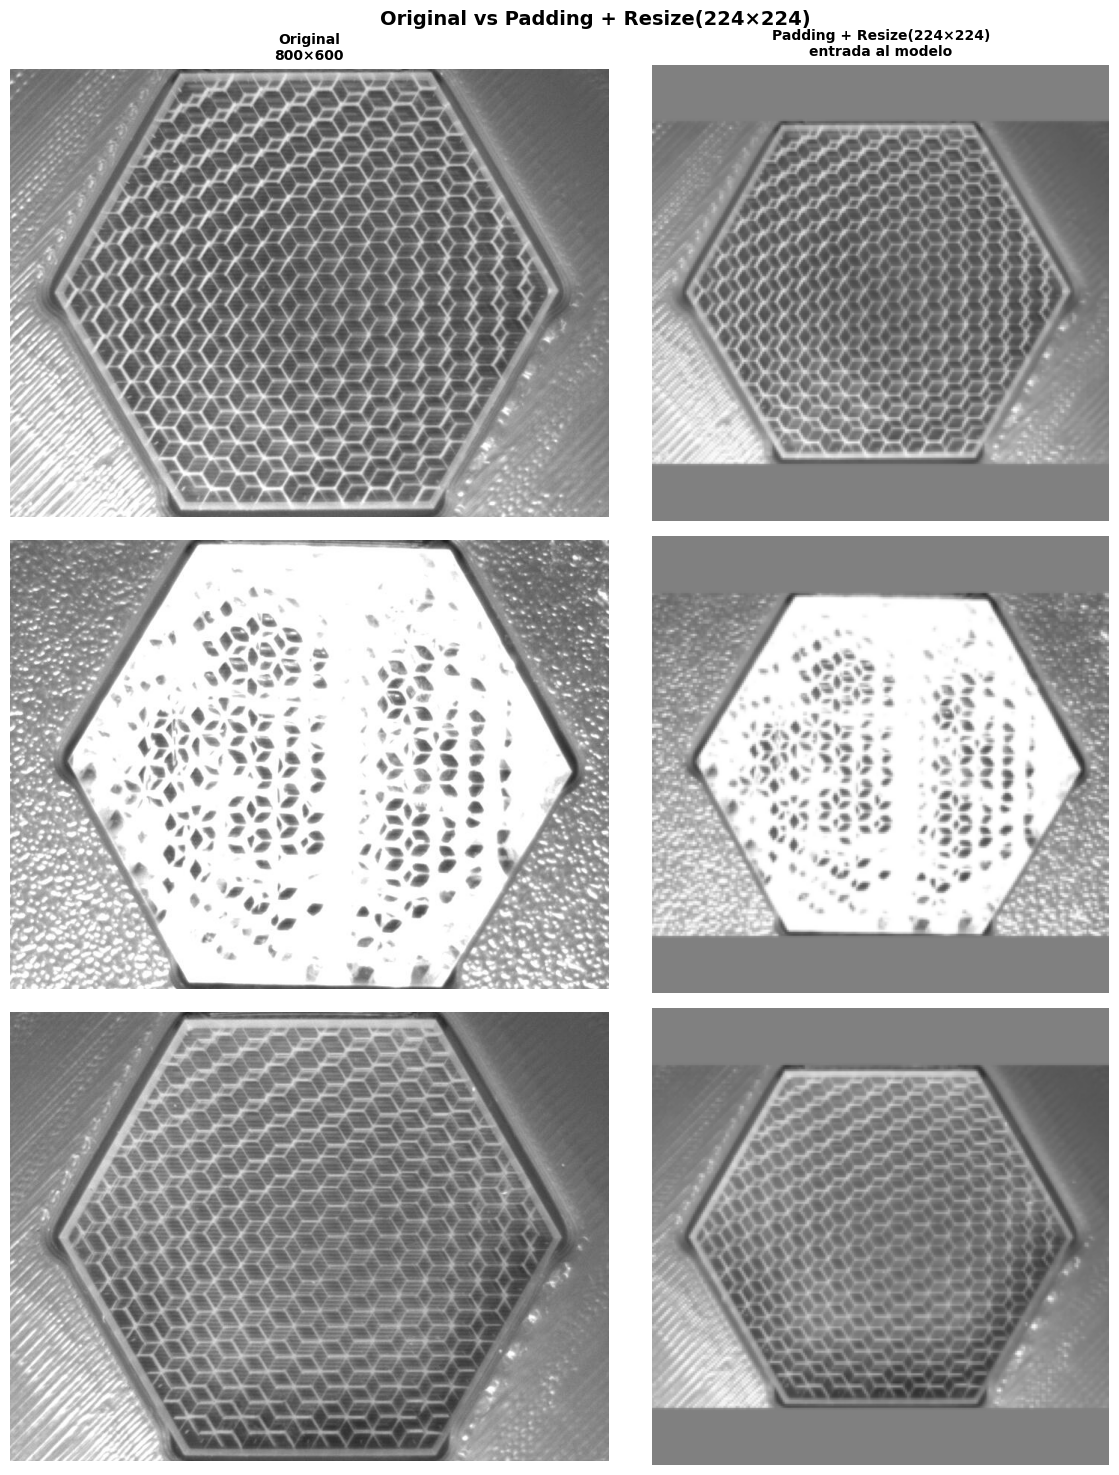

In [21]:
# ─────────────────────────────────────────────
# 6. VISUALIZACIÓN
# ─────────────────────────────────────────────

def mostrar_curvas(historial):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle("Entrenamiento — Clasificador Cristales PET", fontsize=13)
    epocas = range(1, len(historial["train_loss"]) + 1)

    axes[0].plot(epocas, historial["train_loss"], label="Train", color="#2196F3")
    axes[0].plot(epocas, historial["val_loss"],   label="Val",   color="#F44336")
    axes[0].set_title("Pérdida")
    axes[0].set_xlabel("Época")
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(epocas, [a*100 for a in historial["train_acc"]], label="Train", color="#4CAF50")
    axes[1].plot(epocas, [a*100 for a in historial["val_acc"]],   label="Val",   color="#FF9800")
    axes[1].set_title("Precisión (%)")
    axes[1].set_xlabel("Época")
    axes[1].set_ylim(0, 100)
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{CONFIG['checkpoint_dir']}/curvas.png", dpi=150, bbox_inches="tight")
    plt.show()


def mostrar_matriz_confusion(preds, labels, clases):
    n      = len(clases)
    matriz = np.zeros((n, n), dtype=int)
    for p, l in zip(preds, labels):
        matriz[l][p] += 1

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(matriz, cmap="Blues")
    ax.set_xticks(range(n)); ax.set_xticklabels(clases, rotation=15)
    ax.set_yticks(range(n)); ax.set_yticklabels(clases)
    ax.set_xlabel("Predicción"); ax.set_ylabel("Real")
    ax.set_title("Matriz de confusión — Cristales PET")

    for i in range(n):
        for j in range(n):
            ax.text(j, i, str(matriz[i][j]),
                    ha="center", va="center",
                    color="white" if matriz[i][j] > matriz.max()/2 else "black")

    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.savefig(f"{CONFIG['checkpoint_dir']}/confusion.png", dpi=150, bbox_inches="tight")
    plt.show()

def mostrar_recorte(carpeta=None):
    from PIL import Image

    raw_dir = carpeta or CONFIG["raw_dir"]

    tf = transforms.Compose([
        transforms.Pad((0, 100, 0, 100), fill=128),
        transforms.Resize((224, 224)),
    ])

    fig, axes = plt.subplots(len(CLASES), 2, figsize=(12, 5 * len(CLASES)))
    fig.suptitle("Original vs Padding + Resize(224×224)", fontsize=14, fontweight="bold")

    axes[0, 0].set_title("Original\n800×600", fontsize=10, fontweight="bold")
    axes[0, 1].set_title("Padding + Resize(224×224)\nentrada al modelo", fontsize=10, fontweight="bold")

    for row, clase in enumerate(CLASES):
        carpeta_clase = Path(raw_dir) / clase
        archivos = list(carpeta_clase.glob("*"))
        archivos = [f for f in archivos if f.suffix.lower()
                    in (".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp")]

        if not archivos:
            print(f"[AVISO] No hay imágenes en {carpeta_clase}")
            continue

        img_orig = Image.open(archivos[0]).convert("RGB")
        img_pad  = tf(img_orig)

        axes[row, 0].imshow(img_orig)
        axes[row, 0].set_ylabel(clase, fontsize=12, fontweight="bold")
        axes[row, 0].set_xlabel(f"{img_orig.size[0]}×{img_orig.size[1]} px")
        axes[row, 0].axis("off")

        axes[row, 1].imshow(img_pad)
        axes[row, 1].set_xlabel(f"{img_pad.size[0]}×{img_pad.size[1]} px")
        axes[row, 1].axis("off")

    plt.tight_layout()
    plt.show()

mostrar_recorte()

def mostrar_distribucion():
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle("Distribución del dataset", fontsize=13)

    for ax, split, carpeta in zip(axes, ["Train", "Val"],
                                  [CONFIG["train_dir"], CONFIG["val_dir"]]):
        conteos = []
        for clase in CLASES:
            n = len(list(Path(carpeta, clase).glob("*")))
            conteos.append(n)

        bars = ax.bar(CLASES, conteos, color=["#4CAF50", "#F44336", "#2196F3"])
        ax.set_title(f"{split} — total: {sum(conteos)}")
        ax.set_ylabel("Número de imágenes")
        for bar, c in zip(bars, conteos):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                    str(c), ha="center", va="bottom", fontweight="bold")

    plt.tight_layout()
    plt.savefig(f"{CONFIG['checkpoint_dir']}/distribucion.png", dpi=150, bbox_inches="tight")
    plt.show()

In [22]:
# ─────────────────────────────────────────────
# 7. INFERENCIA
# ─────────────────────────────────────────────

def predecir(ruta_imagen, ruta_modelo=None, umbral_confianza=0.6):
    from PIL import Image

    if ruta_modelo is None:
        ruta_modelo = CONFIG["best_model"]

    checkpoint = torch.load(ruta_modelo, map_location=DEVICE)
    clases = checkpoint["clases"]

    model = crear_modelo(len(clases), freeze_backbone=False)
    model.load_state_dict(checkpoint["model_state"])
    model.eval()

    transform = get_transforms(CONFIG["img_size"], train=False)
    img    = Image.open(ruta_imagen).convert("RGB")
    tensor = transform(img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits    = model(tensor)
        probs     = torch.softmax(logits, dim=1)[0]
        conf, idx = probs.max(0)

    clase     = clases[idx.item()]
    confianza = conf.item()

    if confianza < umbral_confianza:
        estado = "⚠  INCIERTO"
    elif clase == "bien":
        estado = "✓  CRISTAL EN BUEN ESTADO"
    elif clase == "mal":
        estado = "✗  CRISTAL EN MAL ESTADO"
    else:
        estado = "△  POCA DENSIDAD"

    print(f"\n[RESULTADO] {estado}")
    print(f"  Clase:     {clase}")
    print(f"  Confianza: {confianza*100:.1f}%")
    for i, c in enumerate(clases):
        print(f"  {c}: {probs[i]*100:.1f}%")

    return clase, confianza

[INFO] Las carpetas train/val ya existen, saltando split.


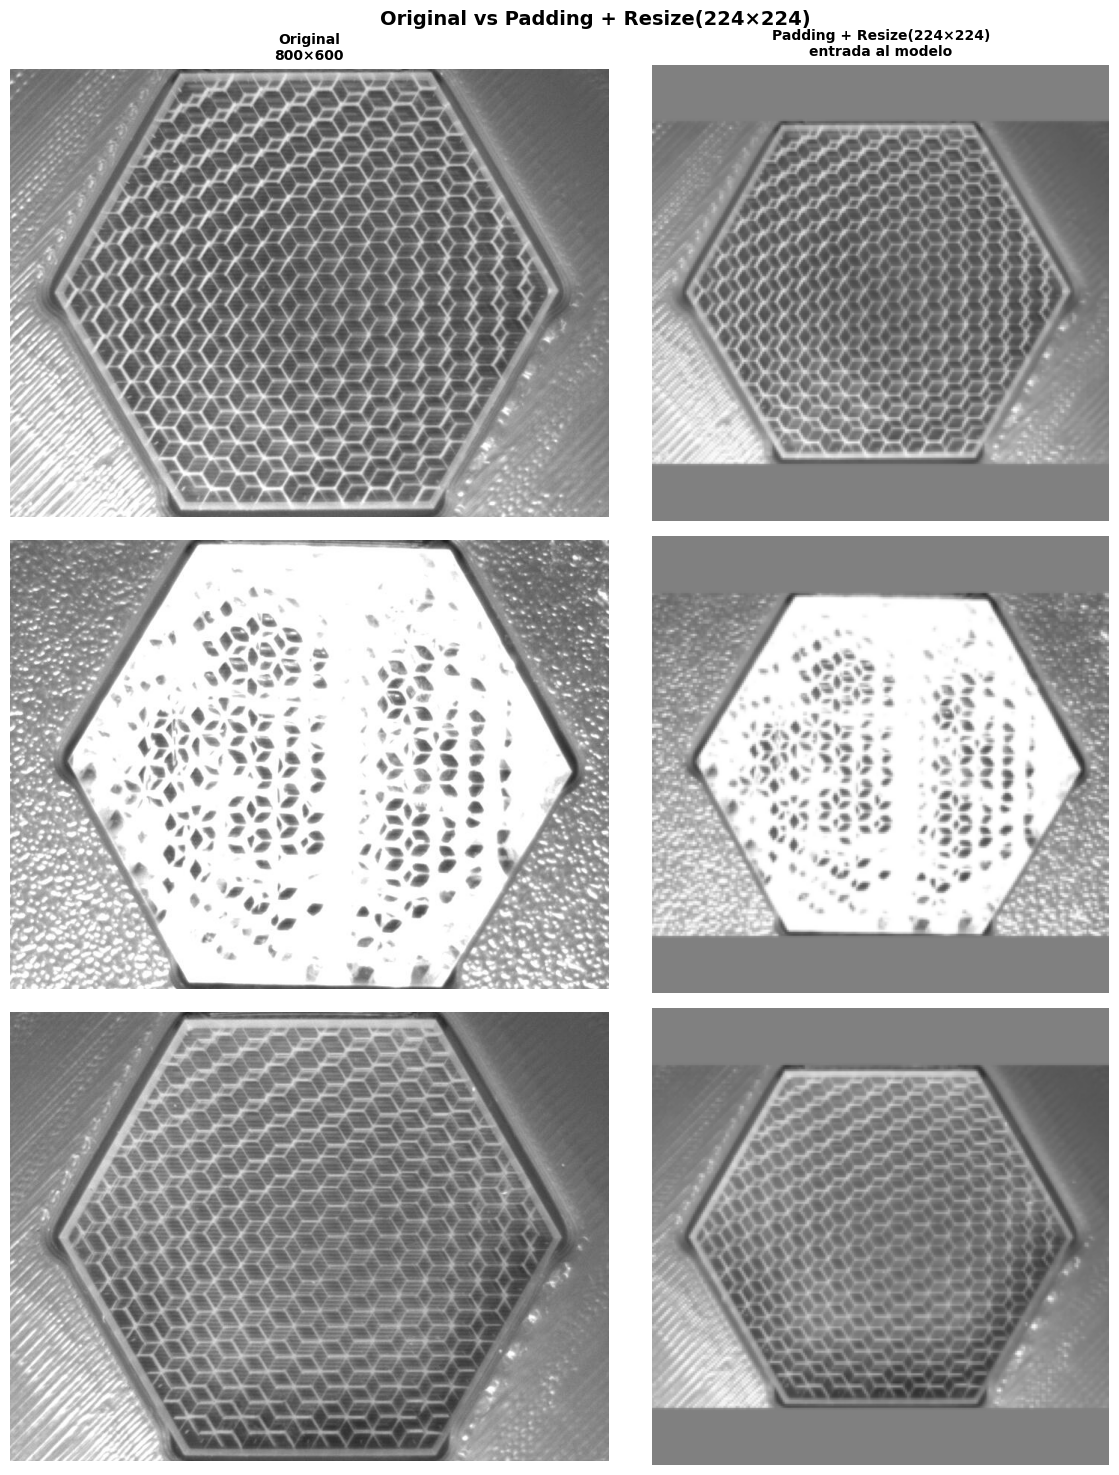

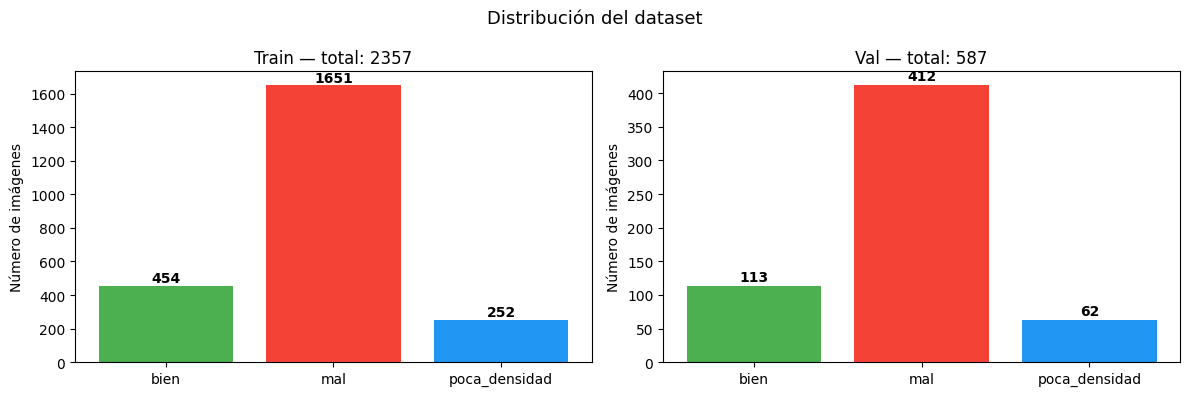


[INFO] Clases detectadas: ['bien', 'mal', 'poca_densidad']
[INFO] Distribución train:
  bien: 454 imágenes
  mal: 1651 imágenes
  poca_densidad: 252 imágenes

[INFO] Train: 2357 | Val: 587

[INFO] Parámetros entrenables: 3,843 / 4,011,391

Epoca [1/35]


  Loss  → Train: 0.8878 | Val: 1.3263
  Acc   → Train: 46.4% | Val: 22.3%
  Score combinado: 0.0905
  ✓ Mejor modelo guardado (acc=22.3% | loss=1.3263 | score=0.0905)

Epoca [2/35]


  Loss  → Train: 0.6838 | Val: 1.3330
  Acc   → Train: 53.9% | Val: 26.7%
  Score combinado: 0.1342
  ✓ Mejor modelo guardado (acc=26.7% | loss=1.3330 | score=0.1342)

Epoca [3/35]


  Loss  → Train: 0.5770 | Val: 1.2800
  Acc   → Train: 62.1% | Val: 32.2%
  Score combinado: 0.1940
  ✓ Mejor modelo guardado (acc=32.2% | loss=1.2800 | score=0.1940)

Epoca [4/35]


  Loss  → Train: 0.5258 | Val: 1.2095
  Acc   → Train: 63.7% | Val: 35.8%
  Score combinado: 0.2368
  ✓ Mejor modelo guardado (acc=35.8% | loss=1.2095 | score=0.2368)

Epoca [5/35]


...

  Loss  → Train: 0.0371 | Val: 0.0781
  Acc   → Train: 98.0% | Val: 98.1%
  Score combinado: 0.9735

Epoca [32/35]


  Loss  → Train: 0.0408 | Val: 0.0650
  Acc   → Train: 97.6% | Val: 99.0%
  Score combinado: 0.9833
  ✓ Mejor modelo guardado (acc=99.0% | loss=0.0650 | score=0.9833)

Epoca [33/35]


  Loss  → Train: 0.0347 | Val: 0.0766
  Acc   → Train: 98.3% | Val: 97.8%
  Score combinado: 0.9702

Epoca [34/35]


  Loss  → Train: 0.0354 | Val: 0.0759
  Acc   → Train: 97.5% | Val: 98.5%
  Score combinado: 0.9771

Epoca [35/35]


  Loss  → Train: 0.0350 | Val: 0.0901
  Acc   → Train: 98.0% | Val: 97.3%
  Score combinado: 0.9637

[INFO] Entrenamiento completado. Mejor score: 0.9833


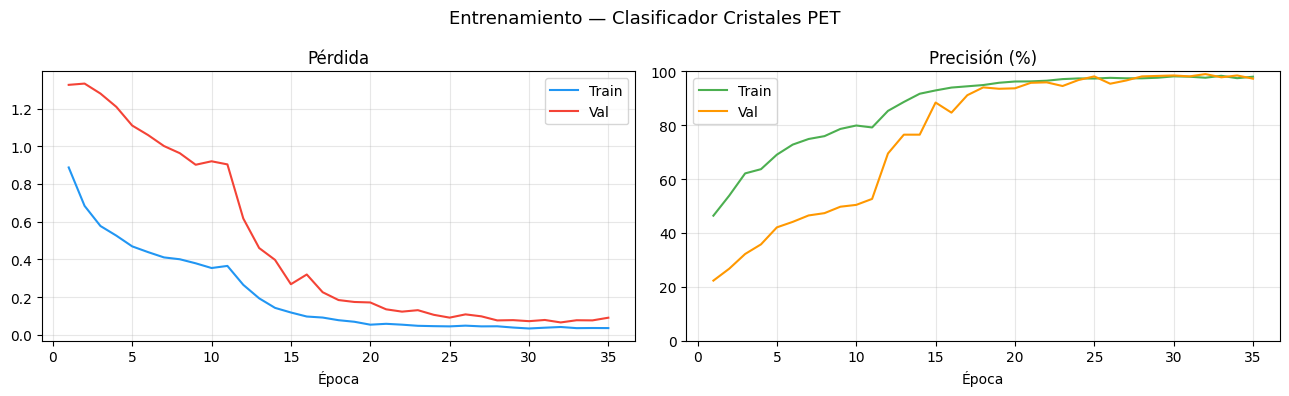


[INFO] Cargando mejor modelo para la matriz de confusión...
[INFO] Mejor modelo → época 32 | acc=99.0% | loss=0.0650 | score=0.9833

[INFO] Clases detectadas: ['bien', 'mal', 'poca_densidad']
[INFO] Distribución train:
  bien: 454 imágenes
  mal: 1651 imágenes
  poca_densidad: 252 imágenes

[INFO] Train: 2357 | Val: 587


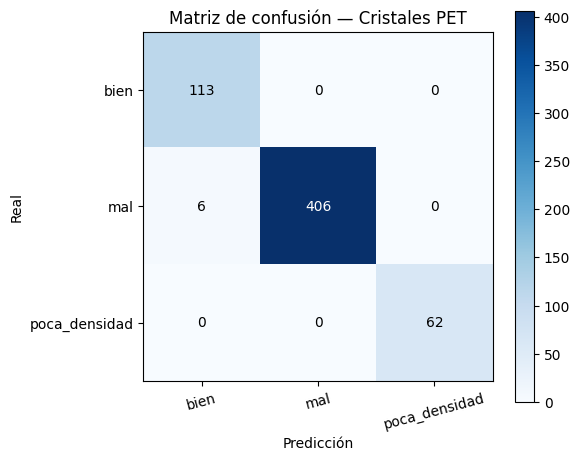


[INFO] Tiempo total de entrenamiento: 0h 19min 13s


In [25]:
# ─────────────────────────────────────────────
# 8. MAIN — ejecuta todo en orden
# ─────────────────────────────────────────────

import time

inicio = time.time()
os.makedirs(CONFIG["checkpoint_dir"], exist_ok=True)

# Paso 1: dividir datos en train/val
auto_split(CONFIG["raw_dir"], CONFIG["train_dir"], CONFIG["val_dir"],
           val_ratio=CONFIG["val_split"])

# Paso 2: ver cómo se recortan las imágenes
mostrar_recorte()

# Paso 3: ver distribución de clases
mostrar_distribucion()

# Paso 4: entrenar
model, historial, clases= entrenar(CONFIG)

# Paso 5: resultados
mostrar_curvas(historial)

# Paso 6: cargar el MEJOR modelo para la matriz de confusión
# (puede no ser la última época, sino la de mayor score)
print("\n[INFO] Cargando mejor modelo para la matriz de confusión...")
checkpoint = torch.load(CONFIG["best_model"], map_location=DEVICE)
model.load_state_dict(checkpoint["model_state"])
print(f"[INFO] Mejor modelo → época {checkpoint['epoca']} | "
      f"acc={checkpoint['val_acc']*100:.1f}% | "
      f"loss={checkpoint['val_loss']:.4f} | "
      f"score={checkpoint['score']:.4f}")

_, val_loader, _, _ = cargar_datos(CONFIG)
criterion_val = nn.CrossEntropyLoss()
_, _, preds_best, labels_best = validar(model, val_loader, criterion_val)
mostrar_matriz_confusion(preds_best, labels_best, clases)

# Calculo tiempo de ejecución
fin = time.time()
segundos = fin - inicio
horas = int(segundos // 3600)
minutos = int((segundos % 3600) // 60)
segs = int(segundos % 60)
print(f"\n[INFO] Tiempo total de entrenamiento: {horas}h {minutos}min {segs}s")

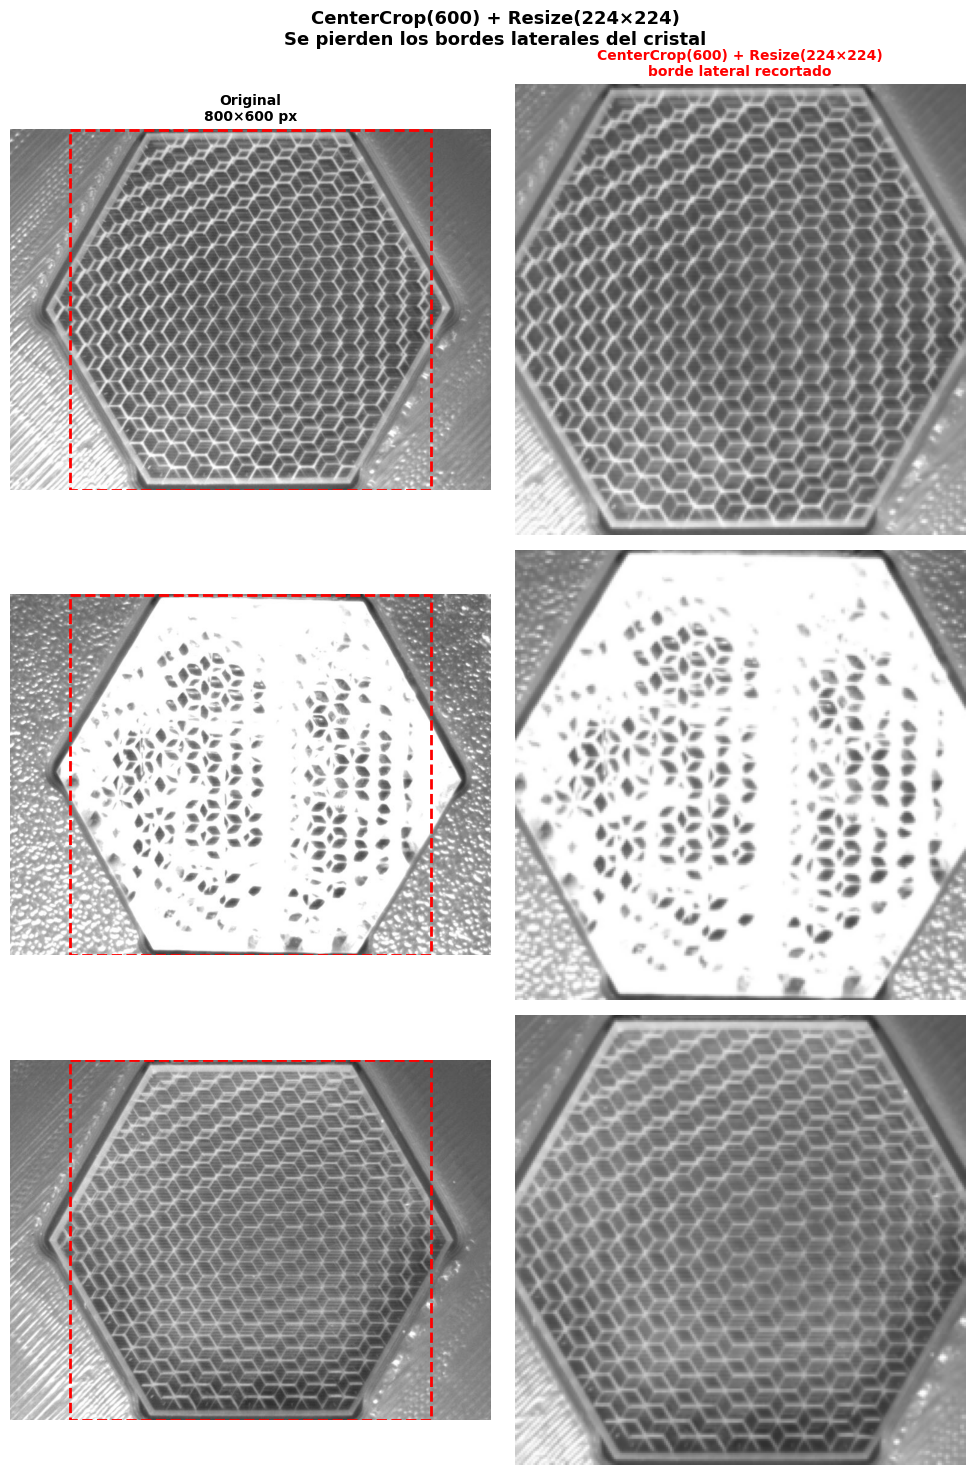

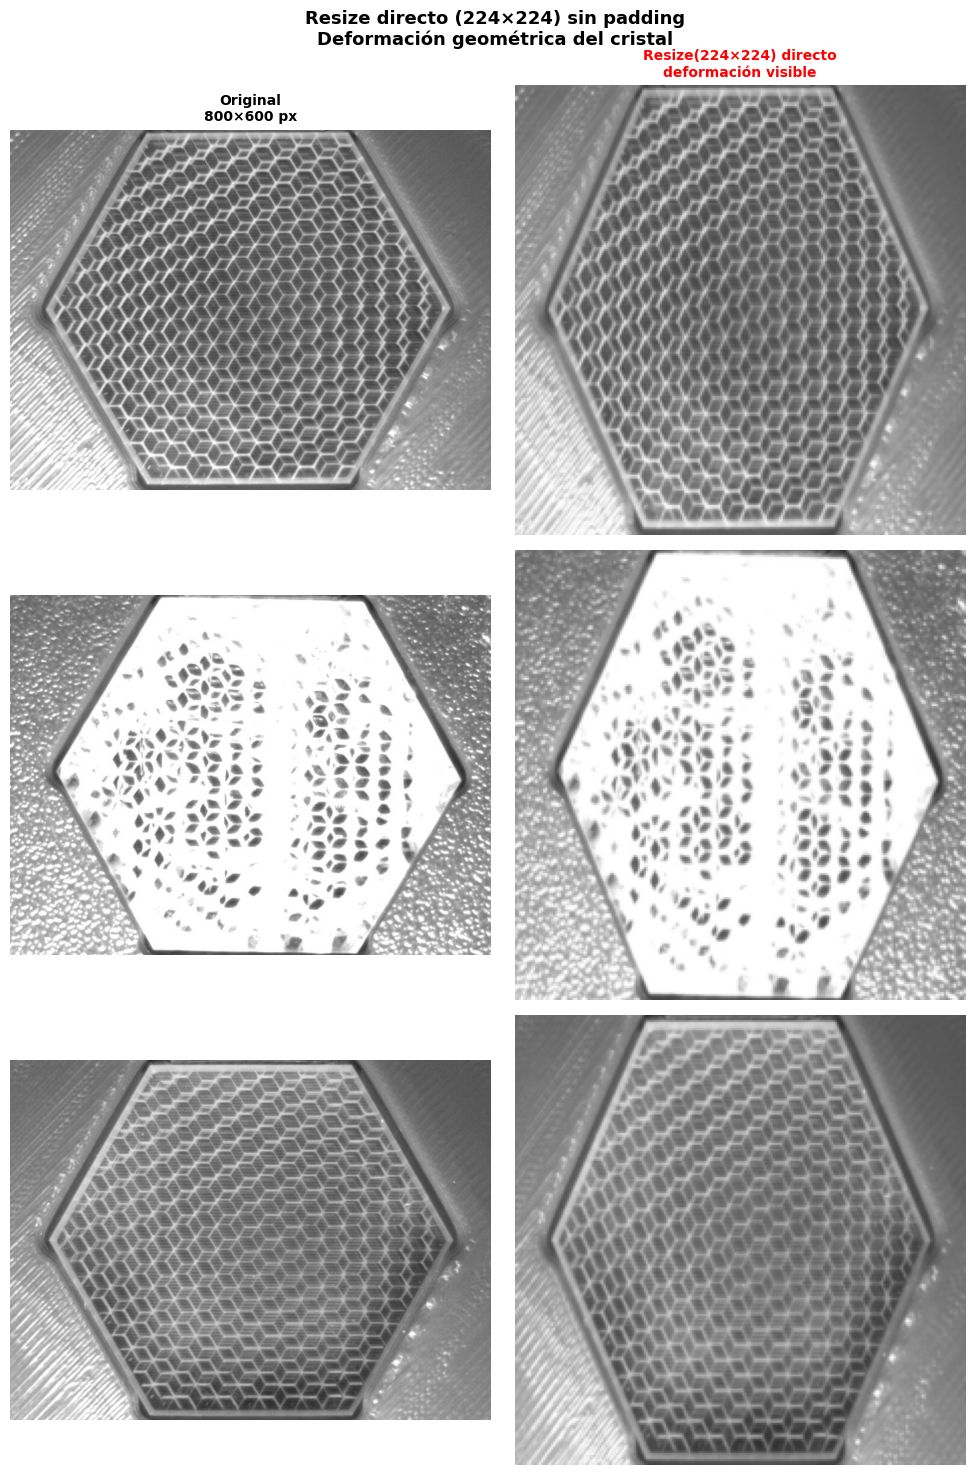

In [ ]:
# ─────────────────────────────────────────────
# 8. EXTRA — código para mostrar recorte en las imágenes
# ─────────────────────────────────────────────

from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from torchvision import transforms
from pathlib import Path

def mostrar_centercrop600(carpeta=None):
    raw_dir = carpeta or CONFIG["raw_dir"]
    tf_crop = transforms.Compose([
        transforms.CenterCrop(600),
        transforms.Resize((224, 224)),
    ])

    fig, axes = plt.subplots(len(CLASES), 2, figsize=(10, 5 * len(CLASES)))
    fig.suptitle("CenterCrop(600) + Resize(224×224)\nSe pierden los bordes laterales del cristal",
                 fontsize=13, fontweight="bold")
    axes[0, 0].set_title("Original\n800×600 px", fontsize=10, fontweight="bold")
    axes[0, 1].set_title("CenterCrop(600) + Resize(224×224)\nborde lateral recortado",
                         fontsize=10, fontweight="bold", color="red")

    for row, clase in enumerate(CLASES):
        archivos = [f for f in (Path(raw_dir) / clase).glob("*")
                    if f.suffix.lower() in (".png", ".jpg", ".jpeg", ".tif", ".bmp")]
        if not archivos:
            continue

        img_orig = Image.open(archivos[0]).convert("RGB")
        img_crop = tf_crop(img_orig)

        axes[row, 0].imshow(img_orig)
        rect = patches.Rectangle((100, 0), 600, 600,
                                   linewidth=2, edgecolor='red',
                                   facecolor='none', linestyle='--')
        axes[row, 0].add_patch(rect)
        axes[row, 0].set_ylabel(clase, fontsize=12, fontweight="bold")
        axes[row, 0].set_xlabel("Rojo = zona conservada | Fuera = descartado")
        axes[row, 0].axis("off")

        axes[row, 1].imshow(img_crop)
        axes[row, 1].set_xlabel("224×224 px")
        axes[row, 1].axis("off")

    plt.tight_layout()
    plt.savefig("figura_centercrop600.png", dpi=150, bbox_inches="tight")
    plt.show()


def mostrar_resize_deformado(carpeta=None):
    raw_dir = carpeta or CONFIG["raw_dir"]
    tf_resize = transforms.Resize((224, 224))

    fig, axes = plt.subplots(len(CLASES), 2, figsize=(10, 5 * len(CLASES)))
    fig.suptitle("Resize directo (224×224) sin padding\nDeformación geométrica del cristal",
                 fontsize=13, fontweight="bold")
    axes[0, 0].set_title("Original\n800×600 px", fontsize=10, fontweight="bold")
    axes[0, 1].set_title("Resize(224×224) directo\ndeformación visible",
                         fontsize=10, fontweight="bold", color="red")

    for row, clase in enumerate(CLASES):
        archivos = [f for f in (Path(raw_dir) / clase).glob("*")
                    if f.suffix.lower() in (".png", ".jpg", ".jpeg", ".tif", ".bmp")]
        if not archivos:
            continue

        img_orig   = Image.open(archivos[0]).convert("RGB")
        img_resize = tf_resize(img_orig)

        axes[row, 0].imshow(img_orig)
        axes[row, 0].set_ylabel(clase, fontsize=12, fontweight="bold")
        axes[row, 0].set_xlabel("800×600 px — proporción original 4:3")
        axes[row, 0].axis("off")

        axes[row, 1].imshow(img_resize)
        axes[row, 1].set_xlabel("224×224 px — proporción forzada 1:1")
        axes[row, 1].axis("off")

    plt.tight_layout()
    plt.savefig("figura_resize_deformado.png", dpi=150, bbox_inches="tight")
    plt.show()


mostrar_centercrop600()
mostrar_resize_deformado()